# 03 - Feature Engineering and Preprocessing

**Project:** Predictive Maintenance - Maintenance Required Prediction
**Goal:** Remove leaky and useless columns, engineer new features, encode categoricals,
scale numerics, and save a clean dataset ready for modeling.

---

## 1. Setup

In [1]:
# Import all libraries needed for feature engineering and preprocessing.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load the raw dataset.
df = pd.read_csv("../data/raw/logistics_dataset_with_maintenance_required.csv")
print(f"Raw dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Raw dataset: 92,000 rows x 27 columns


## 2. Remove Leaky and Useless Columns

The following columns are removed before any modeling:

| Column | Reason |
|--------|--------|
| `Predictive_Score` | Pre-computed risk score - direct leakage of target |
| `Maintenance_Cost` | Known only after maintenance is performed |
| `Maintenance_Type` | Known only after maintenance is performed |
| `Downtime_Maintenance` | Recorded only after the maintenance event |
| `Engine_Temperature` | Constant (120.0 for all rows) - zero variance |
| `Battery_Status` | Only 2 unique values (45.0 / 50.0) - near-constant |
| `Vehicle_ID` | Identifier, not a feature |

In [3]:
# Drop all leaky, constant, and identifier columns from the dataset.
DROP_COLS = [
    "Predictive_Score",
    "Maintenance_Cost",
    "Maintenance_Type",
    "Downtime_Maintenance",
    "Engine_Temperature",
    "Battery_Status",
    "Vehicle_ID",
]

df_clean = df.drop(columns=DROP_COLS)
print(f"Columns after dropping:  {df_clean.shape[1]}  (removed {len(DROP_COLS)})")
print(f"Remaining columns: {df_clean.columns.tolist()}")

Columns after dropping:  20  (removed 7)
Remaining columns: ['Make_and_Model', 'Year_of_Manufacture', 'Vehicle_Type', 'Usage_Hours', 'Route_Info', 'Load_Capacity', 'Actual_Load', 'Last_Maintenance_Date', 'Tire_Pressure', 'Fuel_Consumption', 'Vibration_Levels', 'Oil_Quality', 'Brake_Condition', 'Failure_History', 'Anomalies_Detected', 'Maintenance_Required', 'Weather_Conditions', 'Road_Conditions', 'Delivery_Times', 'Impact_on_Efficiency']


## 3. Feature Engineering

We create new features that capture domain knowledge about vehicle condition.
Think of it like the service logbook of a car: the raw date tells you little,
but 'days since last service' is immediately meaningful.

In [4]:
# Create vehicle_age from Year_of_Manufacture.
df_clean["vehicle_age"] = 2024 - df_clean["Year_of_Manufacture"]
print("vehicle_age sample:", df_clean["vehicle_age"].describe().round(1).to_dict())

vehicle_age sample: {'count': 92000.0, 'mean': 7.0, 'std': 5.4, 'min': 2.0, '25%': 3.0, '50%': 4.0, '75%': 11.0, 'max': 19.0}


In [5]:
# Create overload_ratio as Actual_Load divided by Load_Capacity.
df_clean["overload_ratio"] = df_clean["Actual_Load"] / df_clean["Load_Capacity"]
print("overload_ratio sample:", df_clean["overload_ratio"].describe().round(3).to_dict())

overload_ratio sample: {'count': 92000.0, 'mean': 0.949, 'std': 0.144, 'min': 0.7, '25%': 0.825, '50%': 0.949, '75%': 1.074, 'max': 1.2}


In [6]:
# Create is_overloaded flag: 1 if vehicle carries more than its rated capacity.
df_clean["is_overloaded"] = (df_clean["Actual_Load"] > df_clean["Load_Capacity"]).astype(int)
print("is_overloaded distribution:")
print(df_clean["is_overloaded"].value_counts())

is_overloaded distribution:
is_overloaded
0    55432
1    36568
Name: count, dtype: int64


In [7]:
# Create days_since_maintenance from Last_Maintenance_Date.
df_clean["last_maint_dt"]          = pd.to_datetime(df_clean["Last_Maintenance_Date"])
df_clean["days_since_maintenance"] = (pd.Timestamp("2024-12-31") - df_clean["last_maint_dt"]).dt.days
print("days_since_maintenance sample:", df_clean["days_since_maintenance"].describe().round(1).to_dict())

days_since_maintenance sample: {'count': 92000.0, 'mean': 456.9, 'std': 158.3, 'min': 184.0, '25%': 320.0, '50%': 457.0, '75%': 594.0, 'max': 730.0}


In [8]:
# Create maint_season from the maintenance date.
df_clean["last_maint_dt"] = pd.to_datetime(df_clean["Last_Maintenance_Date"])
df_clean["maint_month"]   = df_clean["last_maint_dt"].dt.month
df_clean["maint_season"]  = df_clean["maint_month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3:  "Spring", 4: "Spring", 5: "Spring",
    6:  "Summer", 7: "Summer", 8: "Summer",
    9:  "Autumn", 10: "Autumn", 11: "Autumn",
})
print("maint_season distribution:")
print(df_clean["maint_season"].value_counts())

maint_season distribution:
maint_season
Spring    31049
Winter    25273
Summer    20497
Autumn    15181
Name: count, dtype: int64


In [9]:
# Drop the raw date columns now that we have the derived features.
df_clean = df_clean.drop(columns=["Last_Maintenance_Date", "last_maint_dt",
                                   "Year_of_Manufacture", "maint_month"])
print(f"Shape after feature engineering: {df_clean.shape}")

Shape after feature engineering: (92000, 23)


## 4. Engineered Features vs Target

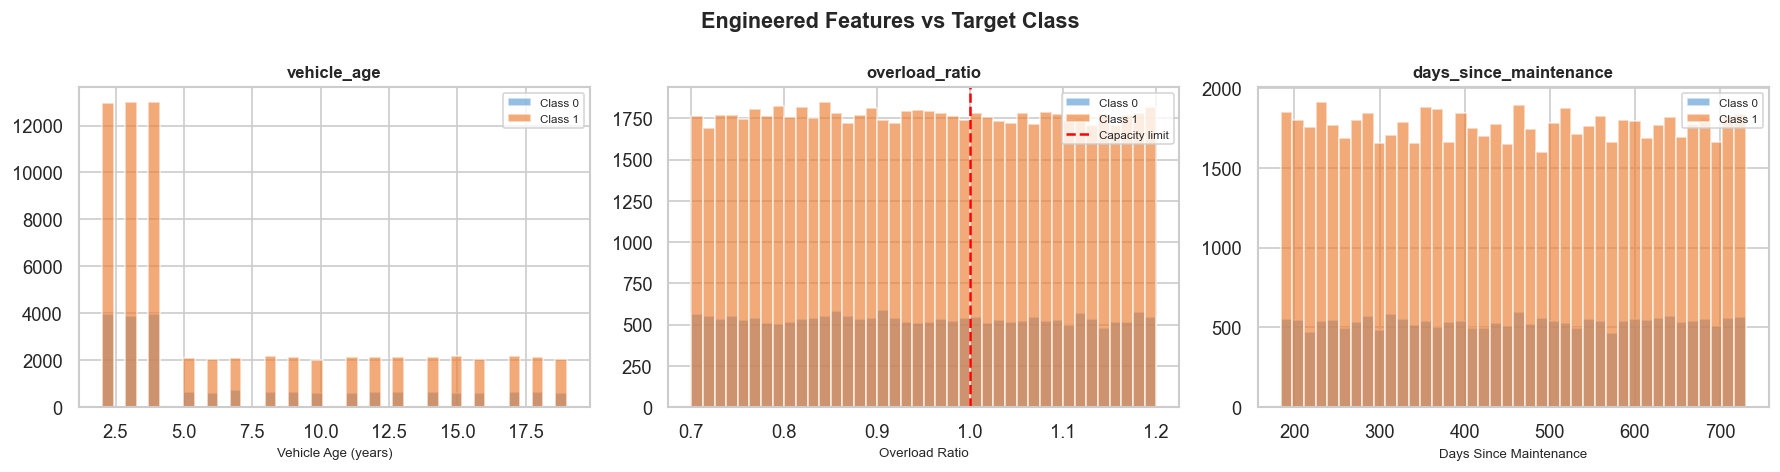

In [10]:
# Visualize how engineered features separate the two target classes.
target_colors = {0: "#5B9BD5", 1: "#ED7D31"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fe_plot = [
    ("vehicle_age",            "Vehicle Age (years)"),
    ("overload_ratio",         "Overload Ratio"),
    ("days_since_maintenance", "Days Since Maintenance"),
]

for ax, (col, xlabel) in zip(axes, fe_plot):
    for cls in [0, 1]:
        ax.hist(df_clean[df_clean["Maintenance_Required"] == cls][col],
                bins=40, alpha=0.65, color=target_colors[cls],
                label=f"Class {cls}", edgecolor="white")
    if col == "overload_ratio":
        ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="Capacity limit")
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle("Engineered Features vs Target Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/17_engineered_vs_target.png", bbox_inches="tight")
plt.show()

## 5. Encoding Categorical Features

In [11]:
# Identify remaining categorical columns before encoding.
cat_cols = df_clean.select_dtypes(include=["object", "string"]).columns.tolist()
print("Categorical columns to encode:", cat_cols)
for col in cat_cols:
    print(f"  {col}: {df_clean[col].unique().tolist()}")

Categorical columns to encode: ['Make_and_Model', 'Vehicle_Type', 'Route_Info', 'Brake_Condition', 'Weather_Conditions', 'Road_Conditions', 'maint_season']
  Make_and_Model: ['Ford F-150', 'Volvo FH', 'Chevy Silverado', 'Tesla Semi']
  Vehicle_Type: ['Truck', 'Van']
  Route_Info: ['Rural', 'Urban', 'Highway']
  Brake_Condition: ['Good', 'Fair', 'Poor']
  Weather_Conditions: ['Clear', 'Rainy', 'Windy', 'Snowy']
  Road_Conditions: ['Highway', 'Rural', 'Urban']
  maint_season: ['Spring', 'Summer', 'Autumn', 'Winter']


In [12]:
# Apply Label Encoding to all categorical columns.
le = LabelEncoder()
df_encoded = df_clean.copy()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    print(f"  Encoded: {col}")

print(f"\nShape after encoding: {df_encoded.shape}")
df_encoded.head(3)

  Encoded: Make_and_Model
  Encoded: Vehicle_Type
  Encoded: Route_Info
  Encoded: Brake_Condition
  Encoded: Weather_Conditions
  Encoded: Road_Conditions
  Encoded: maint_season

Shape after encoding: (92000, 23)


,Make_and_Model,Vehicle_Type,Usage_Hours,Route_Info,Load_Capacity,Actual_Load,Tire_Pressure,Fuel_Consumption,Vibration_Levels,Oil_Quality,Brake_Condition,Failure_History,Anomalies_Detected,Maintenance_Required,Weather_Conditions,Road_Conditions,Delivery_Times,Impact_on_Efficiency,vehicle_age,overload_ratio,is_overloaded,days_since_maintenance,maint_season
0,1,0,530,1,7.5345,9.0042,20.0000,5.0000,2.2470,80.3938,1,1,0,1,0,0,30.0000,0.1501,2,1.1951,1,632,1
1,3,1,10679,1,7.6717,6.1118,20.0000,5.0000,0.8514,91.3025,0,1,0,1,0,1,30.0000,0.3430,9,0.7967,0,530,2
2,0,1,4181,1,2.9012,3.0061,55.0000,13.0069,4.9846,70.1090,1,1,1,1,0,0,48.6278,0.1000,2,1.0362,1,655,1


## 6. Feature Correlation After Engineering

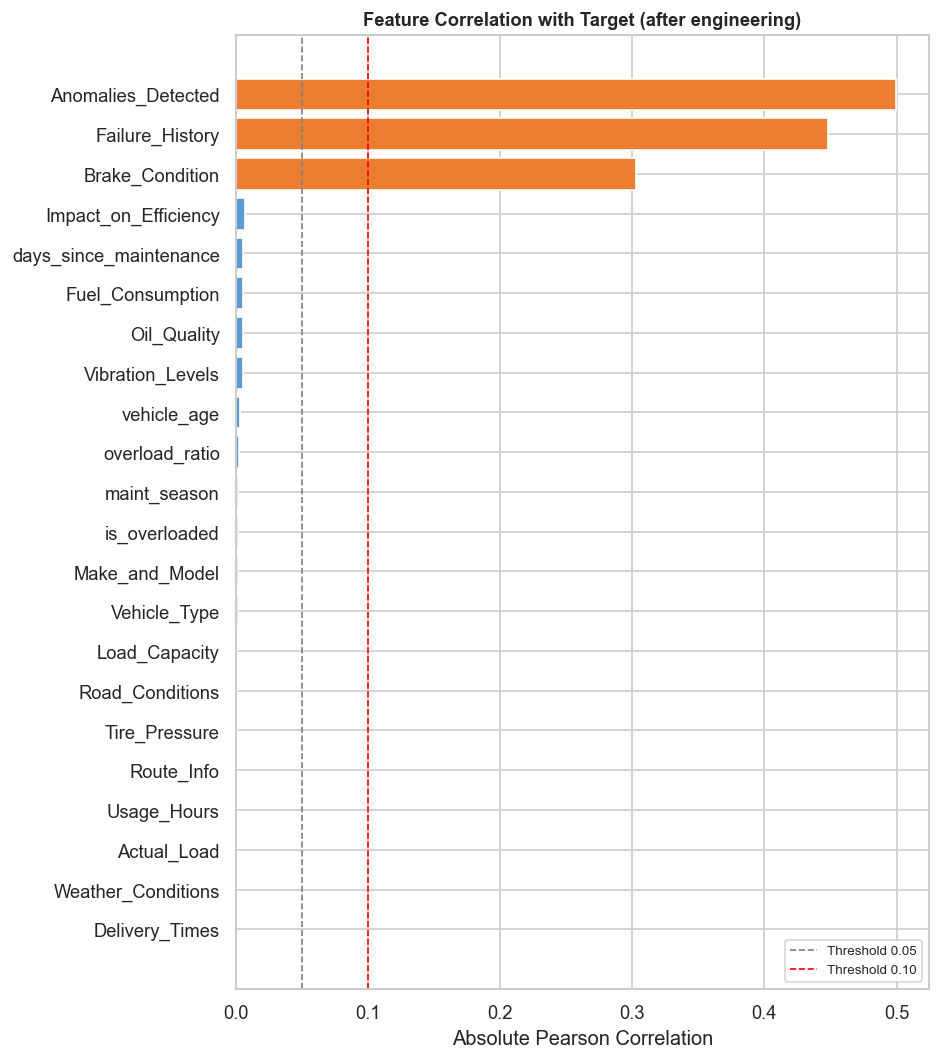

Top 10 features by correlation with target:
Anomalies_Detected       0.4994
Failure_History          0.4484
Brake_Condition          0.3030
Impact_on_Efficiency     0.0071
days_since_maintenance   0.0056
Fuel_Consumption         0.0054
Oil_Quality              0.0053
Vibration_Levels         0.0052
vehicle_age              0.0033
overload_ratio           0.0025


In [13]:
# Compute and plot absolute correlation of all features with the target.
corr = (df_encoded.corr()["Maintenance_Required"]
        .drop("Maintenance_Required")
        .abs()
        .sort_values(ascending=True))

colors = ["#ED7D31" if v > 0.1 else "#5B9BD5" for v in corr.values]

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0.05, color="grey", linestyle="--", linewidth=1, label="Threshold 0.05")
ax.axvline(0.10, color="red",  linestyle="--", linewidth=1, label="Threshold 0.10")
ax.set_title("Feature Correlation with Target (after engineering)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Absolute Pearson Correlation")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../images/18_feature_correlation_final.png", bbox_inches="tight")
plt.show()

print("Top 10 features by correlation with target:")
print(corr.sort_values(ascending=False).head(10).round(4).to_string())

## 7. Train / Test Split

In [14]:
# Separate features and target, then split into train and test sets.
FEATURE_COLS = [c for c in df_encoded.columns if c != "Maintenance_Required"]
TARGET_COL   = "Maintenance_Required"

X = df_encoded[FEATURE_COLS]
y = df_encoded[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]:,} rows  |  Test set: {X_test.shape[0]:,} rows")
print(f"Train target rate: {y_train.mean()*100:.1f}%  |  Test target rate: {y_test.mean()*100:.1f}%")

Train set: 73,600 rows  |  Test set: 18,400 rows
Train target rate: 76.8%  |  Test target rate: 76.8%


## 8. Feature Scaling

In [15]:
# Apply StandardScaler to numerical features (fit on train, transform both sets).
num_cols = X_train.select_dtypes(include="number").columns.tolist()
print(f"Scaling {len(num_cols)} numerical features.")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

print("Scaling complete.")

Scaling 22 numerical features.
Scaling complete.


## 9. Save Processed Datasets

In [16]:
# Save processed train and test splits to the data/processed folder.
import os
os.makedirs("../data/processed", exist_ok=True)

X_train_scaled.to_csv("../data/processed/X_train.csv", index=False)
X_test_scaled.to_csv( "../data/processed/X_test.csv",  index=False)
y_train.to_csv(        "../data/processed/y_train.csv", index=False)
y_test.to_csv(         "../data/processed/y_test.csv",  index=False)

print("Saved:")
print("  data/processed/X_train.csv  -", X_train_scaled.shape)
print("  data/processed/X_test.csv   -", X_test_scaled.shape)
print("  data/processed/y_train.csv  -", y_train.shape)
print("  data/processed/y_test.csv   -", y_test.shape)

Saved:
  data/processed/X_train.csv  - (73600, 22)
  data/processed/X_test.csv   - (18400, 22)
  data/processed/y_train.csv  - (73600,)
  data/processed/y_test.csv   - (18400,)


## 10. Preprocessing Summary

### Steps Completed
1. Dropped 7 columns: 4 leaky, 2 near-constant, 1 identifier.
2. Engineered 4 new features: `vehicle_age`, `overload_ratio`, `is_overloaded`, `days_since_maintenance`.
3. Extracted 1 seasonal feature: `maint_season`.
4. Label-encoded all categorical features.
5. Applied `StandardScaler` (fit on train only to prevent data leakage).
6. Stratified 80/20 train/test split.

### Final Feature Set
- Total features: see `X_train.shape[1]`
- Target: `Maintenance_Required` (binary: 0 / 1)
- Class balance preserved in both splits via stratification.

### Next Step
- **04_Classification.ipynb** - train and evaluate binary classification models.